# 2.1 — Базовые модели (MLP, GRU, TCN)

**Папка 2 «Обучение моделей», подноутбук 1.** Для каждой базовой модели выполняется
**подбор гиперпараметров перебором по сетке (grid search)** с богатой историей (все метрики
по каждой конфигурации). Метрика отбора выбирается явно. Лучшая комбинация сохраняется в
`models/<имя>/hyperparams.json`, после чего финальное обучение **читает этот JSON** и обучает
модель «начисто» с отслеживанием метрик. Рисунки и таблицы — на английском.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import (GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline,
                                    TransformerBaseline, FTTransformer, CatBoostBaseline,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow)

device: cpu | dims static/prefix/seq: 34 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Censored mean absolute error of the predicted ...
5,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
6,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
7,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...
8,ECE,Expected calibration error,–,lower is better,Average absolute gap between predicted confide...
9,Coverage_90,90% interval coverage,–,target ≈ 0.9,Empirical fraction of true PPR values that fal...


## Шаг 1. Grid search, история по всем метрикам и сохранение гиперпараметров

Для каждой модели задана своя метрика отбора `score` (можно менять). Дашборд показывает
все метрики по каждой конфигурации; лучшая по метрике отбора подсвечена.

[MLP-Risk] selection metric = Brier | best = {'hidden_dim': 128}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,128,0.0610,105.9394,362.1135,0.3530,0.5619,115.0,0.4603,121.4052,0.4483,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,64,0.1486,214.5685,596.1631,0.5553,0.9341,115.0,0.7242,255.3957,0.5862,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


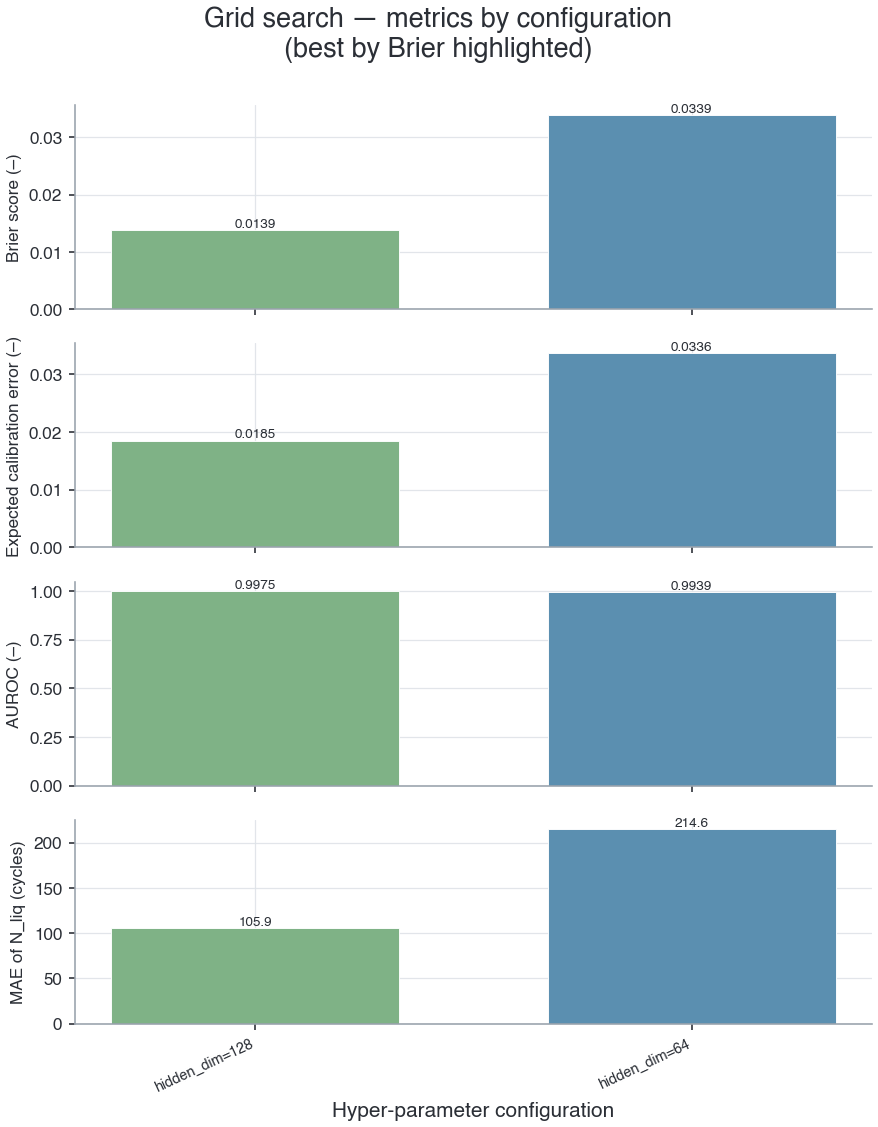

[GRU] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,64,0.2205,1062.9939,1191.8834,2.0395,2.3114,115.0,2.3403,759.7723,0.0,...,0.6913,0.9931,0.8238,0.0889,-0.4368,0.0836,NaN,0.0,0.0,0.0
1,96,-0.5923,774.4926,1176.6395,1.5106,1.7312,115.0,1.5143,274.5312,0.0,...,0.7269,0.9847,0.8662,0.0720,-0.3561,0.0906,NaN,0.0,0.0,0.0


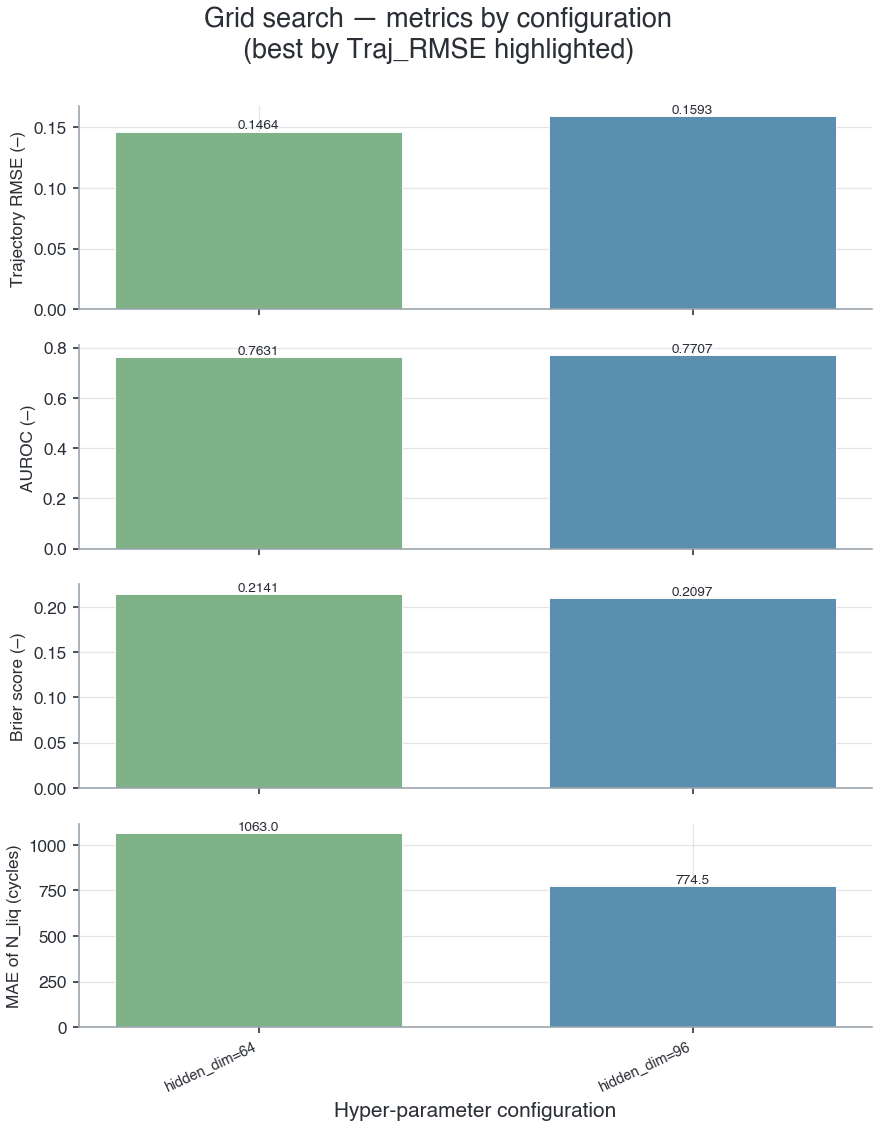

[TCN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-0.8301,393.3277,613.3391,0.8928,1.1619,115.0,1.0575,229.2019,0.3563,...,0.3715,0.8945,0.4427,0.0470,-0.6851,0.0750,NaN,0.0,0.0,0.0
1,64,-1.1858,1454.5137,1555.4326,2.3368,2.7754,115.0,2.9947,1682.3461,0.0115,...,0.4132,0.9247,0.4923,0.0443,-0.5750,0.0806,NaN,0.0,0.0,0.0


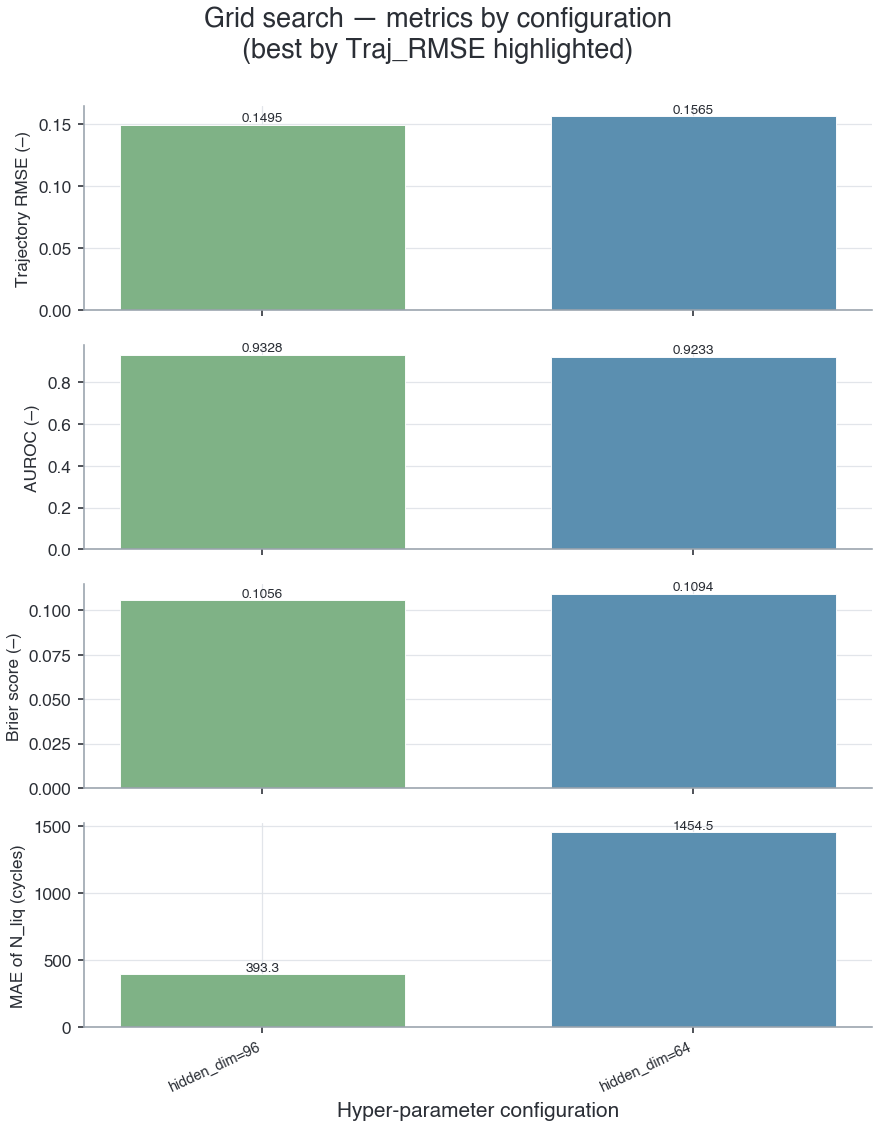

[LSTM] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,0.5250,1374.4863,1380.1393,2.3172,2.6737,115.0,2.8300,1319.4901,0.0,...,0.4867,0.8534,0.5800,0.0807,-0.2030,0.1036,NaN,0.0,0.0,0.0
1,64,-0.0782,1575.3259,1589.9529,2.4416,2.8368,115.0,3.0315,1646.9268,0.0,...,0.5899,0.9525,0.7028,0.0068,-0.3384,0.1050,NaN,0.0,0.0,0.0


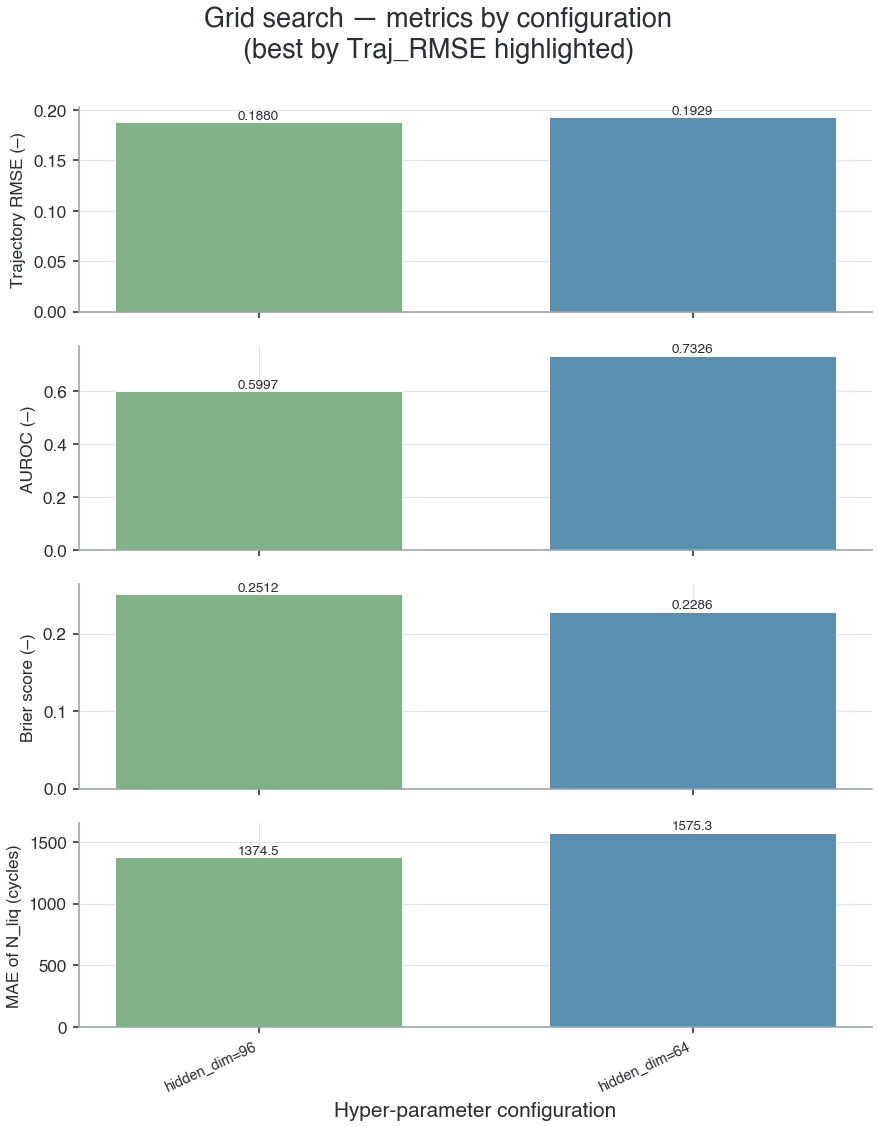

[Transformer] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,-2.2338,713.6582,958.8392,1.4438,1.760,115.0,1.8596,808.5797,0.0000,...,0.1685,0.9013,0.2008,0.0375,-1.3936,0.0323,NaN,0.0,0.0,0.0
1,64,-1.7062,647.4153,823.4373,1.1645,1.444,115.0,1.4071,539.2836,0.0575,...,0.1817,0.9253,0.2166,0.0418,-1.1626,0.0406,NaN,0.0,0.0,0.0


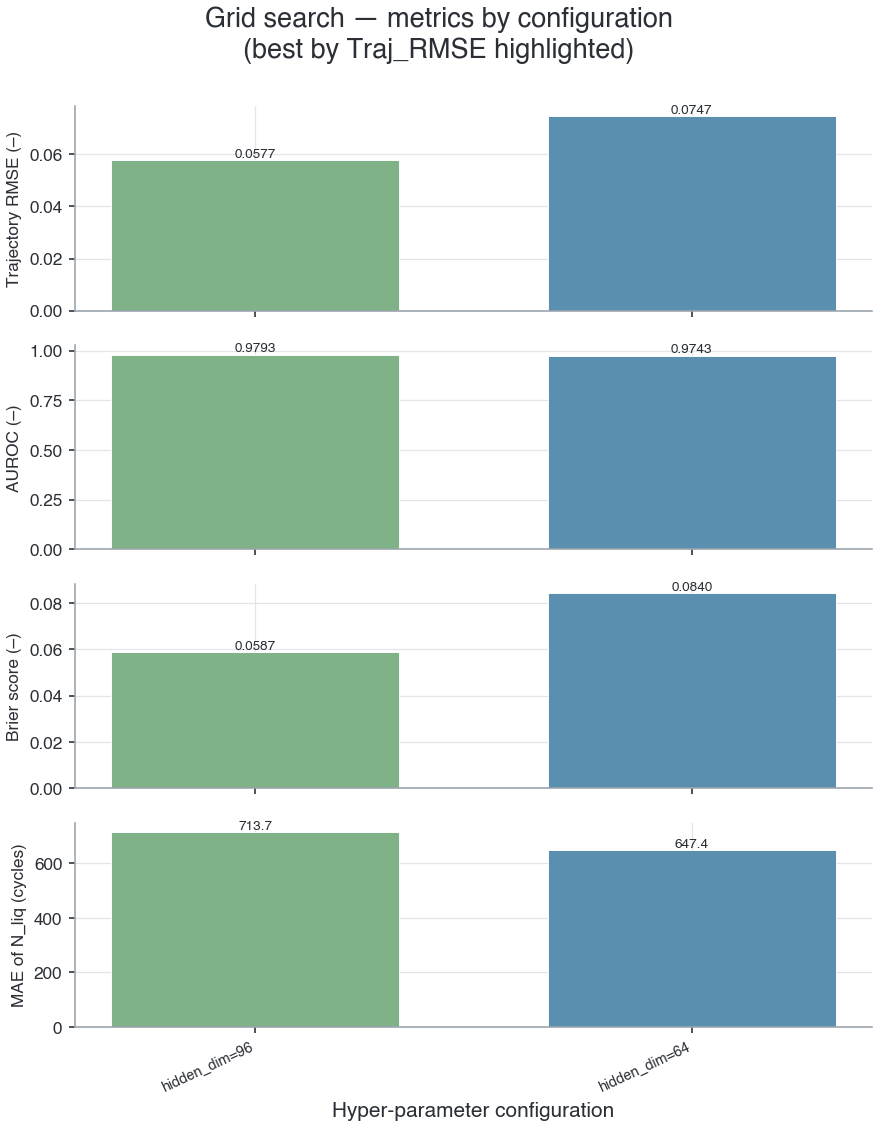

[FT-Transformer] selection metric = Brier | best = {'n_layers': 2}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,2,0.0541,336.9337,604.6230,0.8768,1.1230,115.0,1.1389,387.2438,0.1954,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,3,0.0714,185.0663,415.2108,0.5842,0.8262,115.0,0.7436,162.4053,0.3218,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


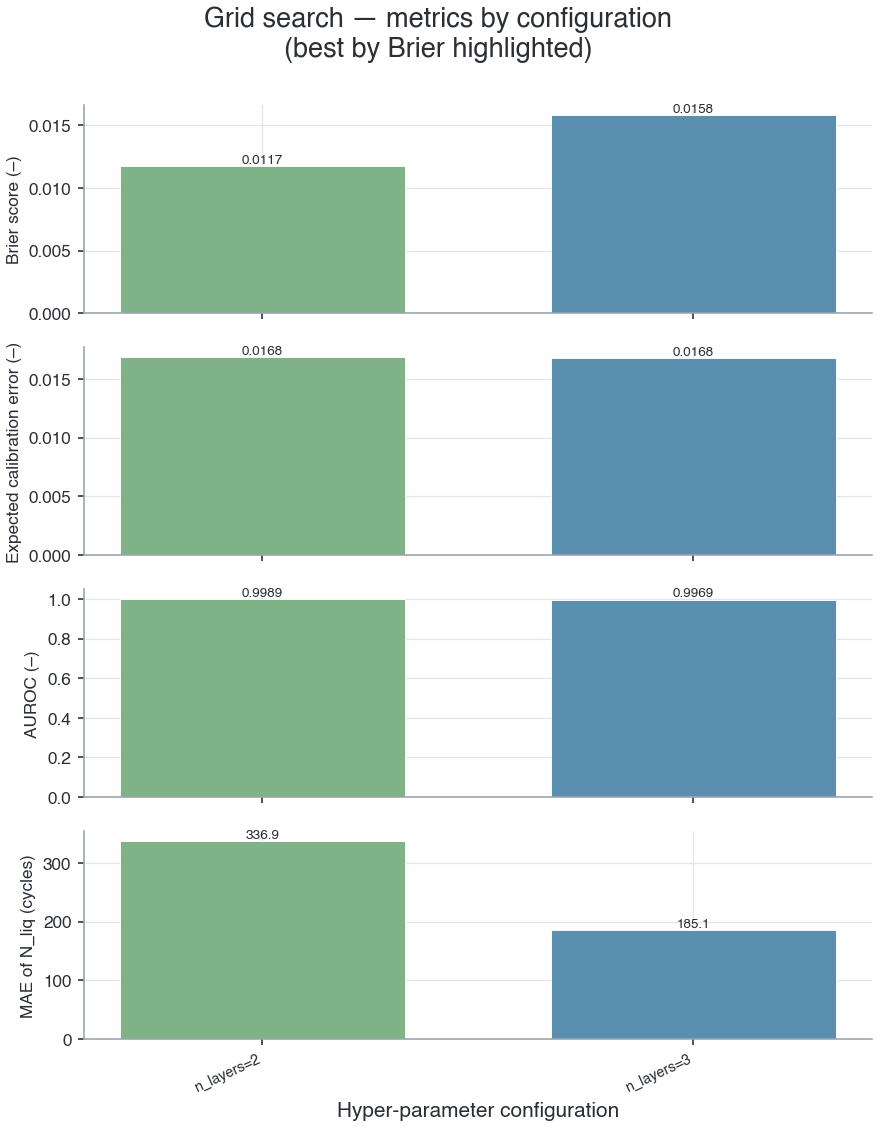

[PINN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,96,0.8661,701.6697,876.0464,1.3564,1.6103,115.0,1.5862,471.0599,0.0115,...,0.3848,0.8748,0.4586,0.1256,-0.3095,0.0995,NaN,0.0,0.0,0.0
1,64,0.2076,880.2440,957.3257,1.8144,2.0765,115.0,2.2051,729.0541,0.0000,...,0.4176,0.8227,0.4976,0.1482,-0.2200,0.1071,NaN,0.0,0.0,0.0


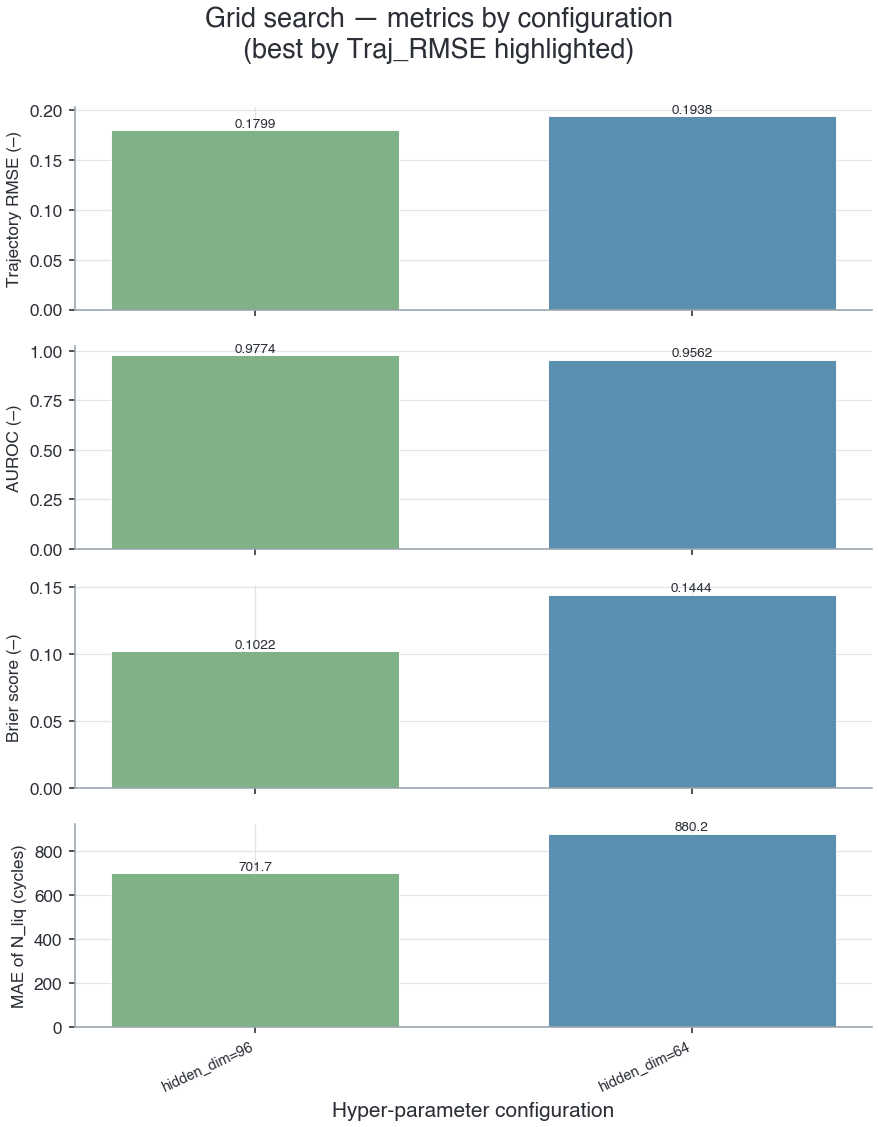

[DeepState] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,64,-0.3214,1170.6740,1202.6760,2.1568,2.4806,115.0,2.5960,1018.9929,0.0,...,0.5947,0.9510,0.7086,0.0278,-0.4794,0.0898,NaN,0.0,0.0,0.0
1,96,-0.9693,843.0942,1115.5912,1.6690,1.9370,115.0,1.8242,447.0463,0.0,...,0.5535,0.9518,0.6595,0.0224,-0.3904,0.1050,NaN,0.0,0.0,0.0


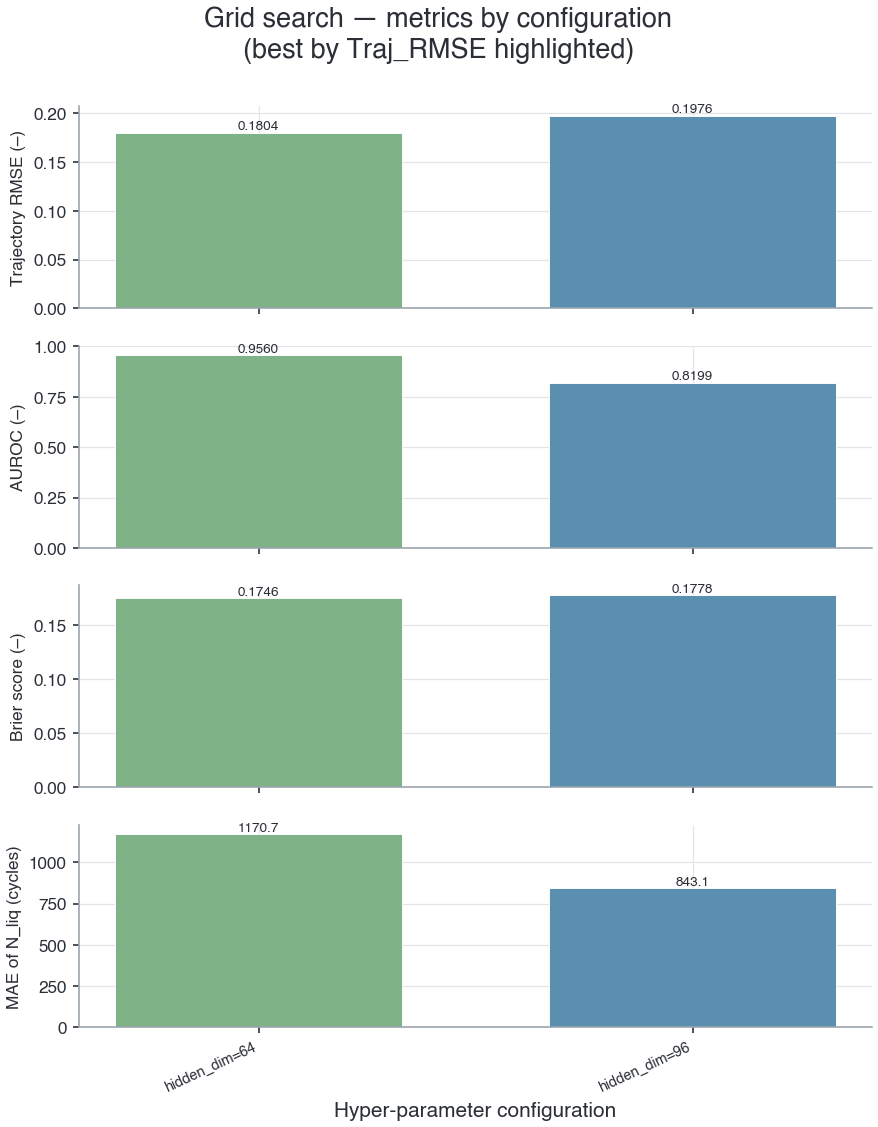

[RealNVP] selection metric = Traj_RMSE | best = {'n_layers': 4}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,4,0.4747,435.6673,680.1439,0.9121,1.0819,115.0,1.0542,252.0305,0.2759,...,0.1598,0.8718,0.1904,0.1306,-1.1839,0.0354,NaN,0.0,0.0,0.0
1,6,0.5531,348.7724,612.6937,0.7812,1.0157,115.0,0.8851,135.9471,0.5172,...,0.2161,0.8826,0.2575,0.1243,-1.0048,0.0480,NaN,0.0,0.0,0.0


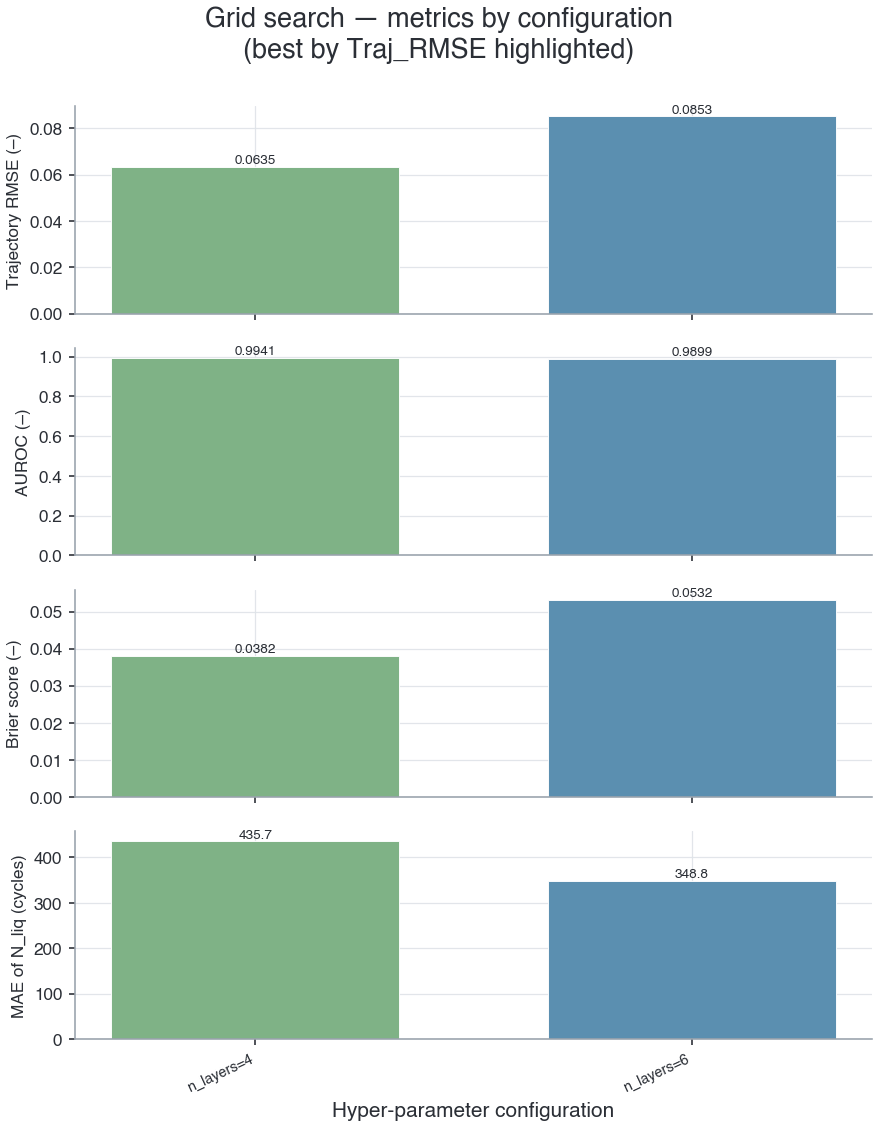

[Neural Spline Flow] selection metric = Traj_RMSE | best = {'n_layers': 4}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,4,7.5354,454.9711,894.9340,0.9428,1.1505,115.0,0.9382,83.5696,0.7816,...,0.2696,0.7888,0.3212,0.1716,-0.4285,0.0528,NaN,0.0,0.0,0.0
1,5,7.4802,462.8934,894.5428,0.8384,1.0355,115.0,0.8018,88.2360,0.6437,...,0.2518,0.7064,0.3001,0.2693,-0.0552,0.0615,NaN,0.0,0.0,0.0


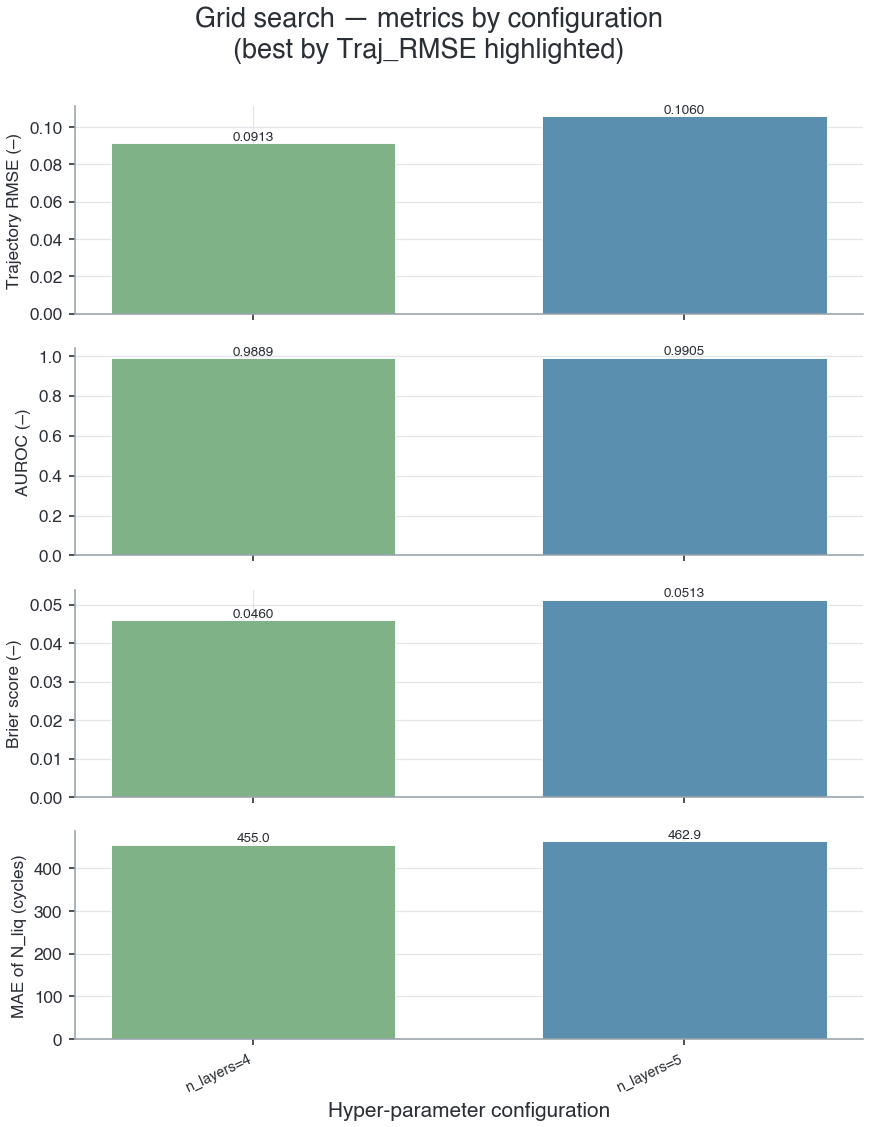

In [3]:
base_specs = {
    "mlp_risk": dict(display="MLP-Risk", cls=RiskMLP,
                     fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                     grid={"hidden_dim": [64, 128]}, score="Brier",
                     metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "gru": dict(display="GRU", cls=GRUBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "tcn": dict(display="TCN", cls=TCNBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "lstm": dict(display="LSTM", cls=LSTMBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "transformer": dict(display="Transformer", cls=TransformerBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim, seq_len=config.seq_len),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "ft_transformer": dict(display="FT-Transformer", cls=FTTransformer,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                 grid={"n_layers": [2, 3]}, score="Brier",
                 metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "pinn": dict(display="PINN", cls=PINNBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "deepstate": dict(display="DeepState", cls=DeepStateBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "realnvp": dict(display="RealNVP", cls=RealNVPFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 6]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "nsf": dict(display="Neural Spline Flow", cls=NeuralSplineFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 5]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
}

for name, spec in base_specs.items():
    cls, fixed, grid, score = spec["cls"], spec["fixed"], spec["grid"], spec["score"]
    res, best = grid_search(lambda p, cls=cls, fixed=fixed: cls(**fixed, **p),
                            grid, gs_train, gs_val, config, device, search_epochs=config.grid_search_epochs, score_metric=score)
    write_hyperparams(MODELS_DIR, name, {"model_type": cls.__name__, "display_name": spec["display"],
                      "model_kwargs": {**fixed, **best}, "search": {"grid": grid, "score_metric": score, "best": best}})
    print(f"[{spec['display']}] selection metric = {score} | best = {best}")
    display(english_metric_table(res).round(4))
    show_grid_dashboard(res, grid, score, spec["metrics"], f"2_1_grid_search_{name}").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
# Реестр классов всех baseline (имя класса -> класс) и число эпох по семействам
CLS = {RiskMLP.__name__: RiskMLP, GRUBaseline.__name__: GRUBaseline, TCNBaseline.__name__: TCNBaseline,
       LSTMBaseline.__name__: LSTMBaseline, TransformerBaseline.__name__: TransformerBaseline,
       FTTransformer.__name__: FTTransformer, PINNBaseline.__name__: PINNBaseline,
       DeepStateBaseline.__name__: DeepStateBaseline, RealNVPFlow.__name__: RealNVPFlow,
       NeuralSplineFlow.__name__: NeuralSplineFlow}
# PINN — физически-структурированная (больше эпох); остальные baseline — config.baseline_epochs
epoch_map = {name: (config.publication_physics_epochs if name == "pinn" else config.publication_baseline_epochs) for name in base_specs}
histories = {}
for name in base_specs:
    hp = read_hyperparams(MODELS_DIR, name)
    model = CLS[hp["model_type"]](**hp["model_kwargs"]).to(device)
    epochs = epoch_map[name]
    model, history = train_model(model, benchmark["train"], benchmark["val"], epochs=epochs,
                                 model_name=hp["display_name"], config=config, device=device, track_metrics=True)
    save_trained_model(model, MODELS_DIR, name, {**hp, "epochs": len(history), "learning_rate": config.learning_rate,
                       "weight_decay": config.weight_decay, "batch_size": config.batch_size, "seed": config.seed}, history)
    histories[hp["display_name"]] = history
    print("saved:", MODELS_DIR / name)

[MLP-Risk] эпоха 01 | обучение=0.5366 | валидация=0.1351 | val_AUROC=0.998 | stale=0/25
[MLP-Risk] эпоха 02 | обучение=0.1518 | валидация=0.1337 | val_AUROC=0.994 | stale=0/25
[MLP-Risk] эпоха 03 | обучение=0.0936 | валидация=0.1192 | val_AUROC=0.996 | stale=0/25
[MLP-Risk] эпоха 04 | обучение=0.0820 | валидация=0.1320 | val_AUROC=0.995 | stale=1/25
[MLP-Risk] эпоха 05 | обучение=0.0671 | валидация=0.1578 | val_AUROC=0.993 | stale=2/25
[MLP-Risk] эпоха 06 | обучение=0.0590 | валидация=0.1512 | val_AUROC=0.993 | stale=3/25
[MLP-Risk] эпоха 07 | обучение=0.0610 | валидация=0.1159 | val_AUROC=0.995 | stale=0/25
[MLP-Risk] эпоха 08 | обучение=0.0517 | валидация=0.1307 | val_AUROC=0.994 | stale=1/25
[MLP-Risk] эпоха 09 | обучение=0.0534 | валидация=0.0957 | val_AUROC=0.996 | stale=0/25
[MLP-Risk] эпоха 10 | обучение=0.0496 | валидация=0.0591 | val_AUROC=0.997 | stale=0/25
[MLP-Risk] эпоха 11 | обучение=0.0492 | валидация=0.0589 | val_AUROC=0.998 | stale=0/25
[MLP-Risk] эпоха 12 | обучение=0

## Кривые обучения с метриками

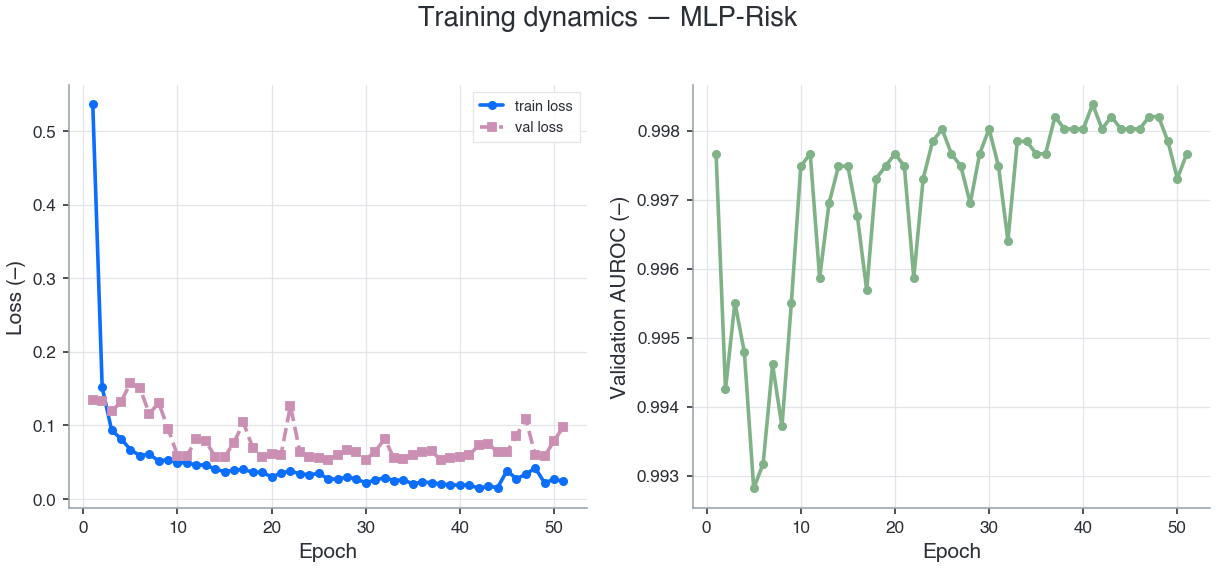

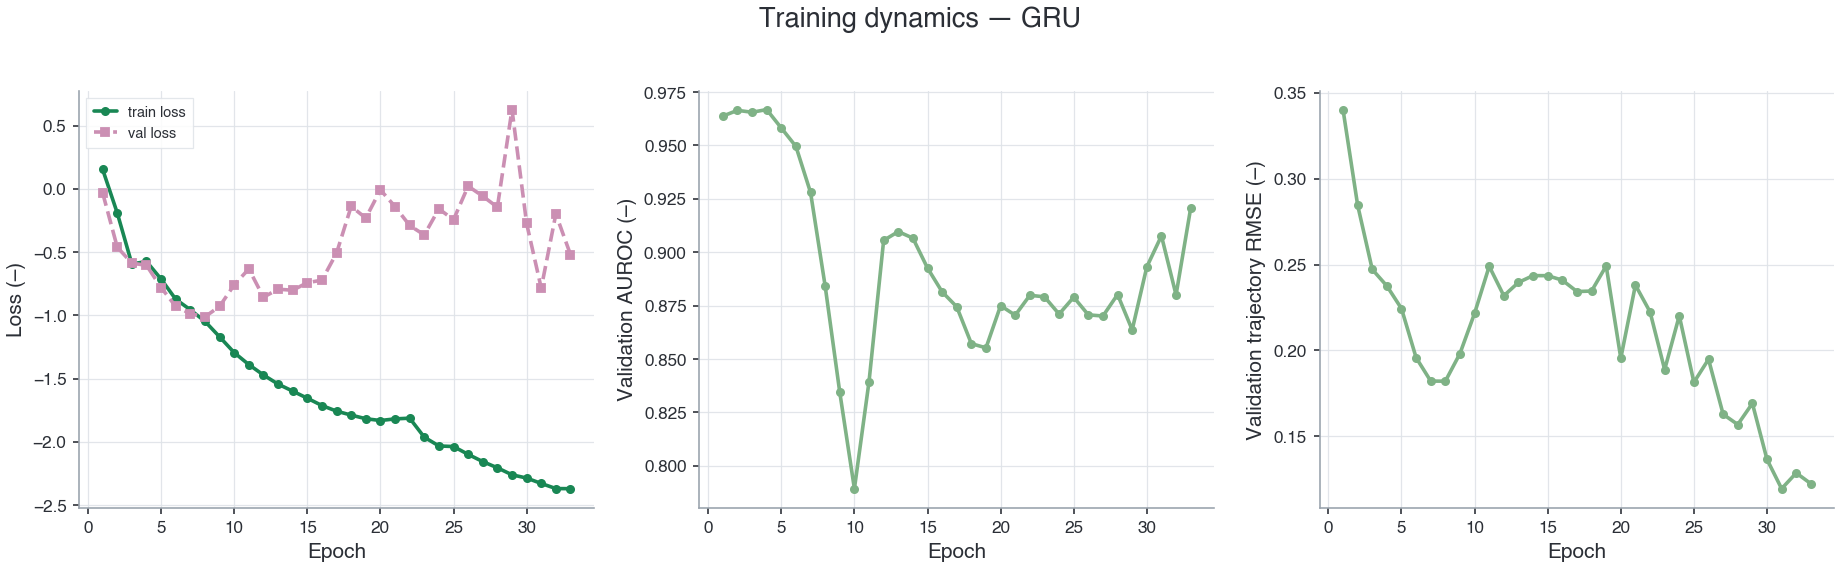

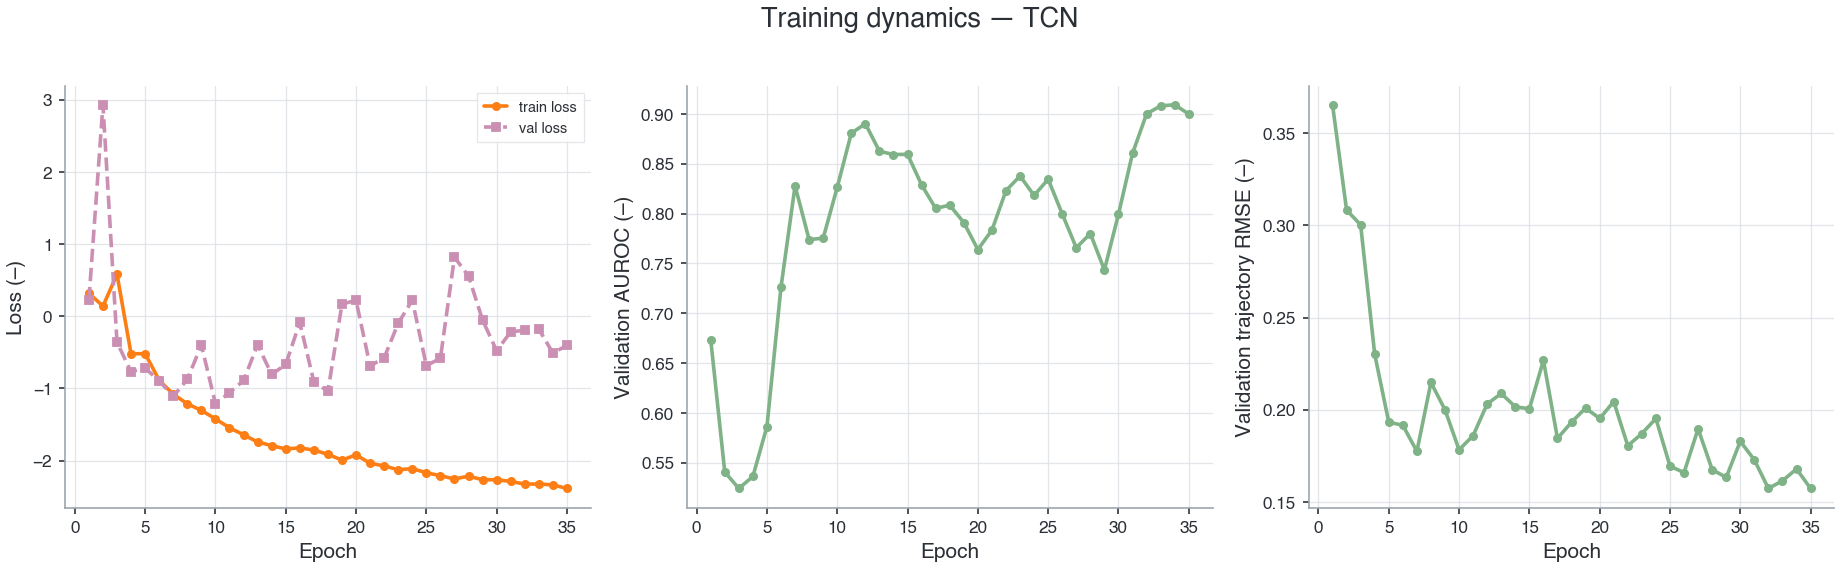

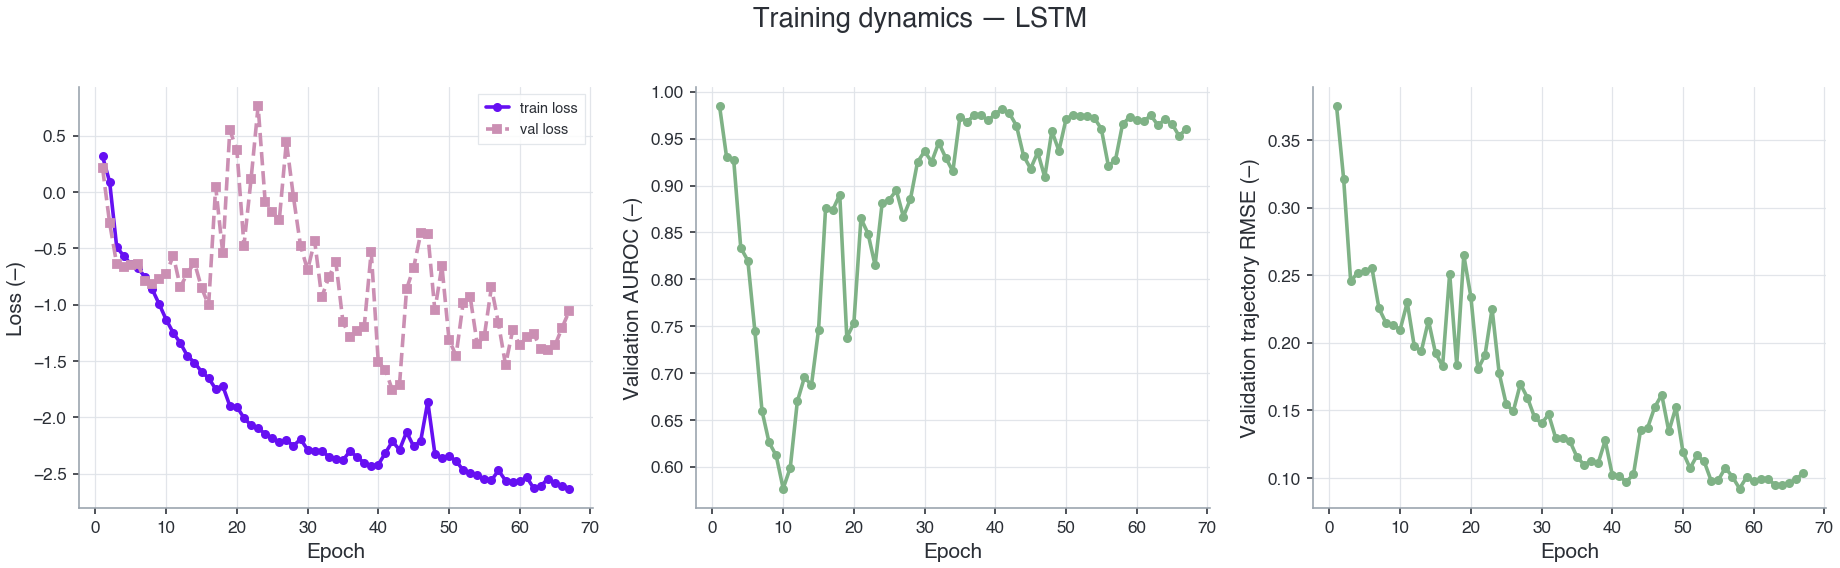

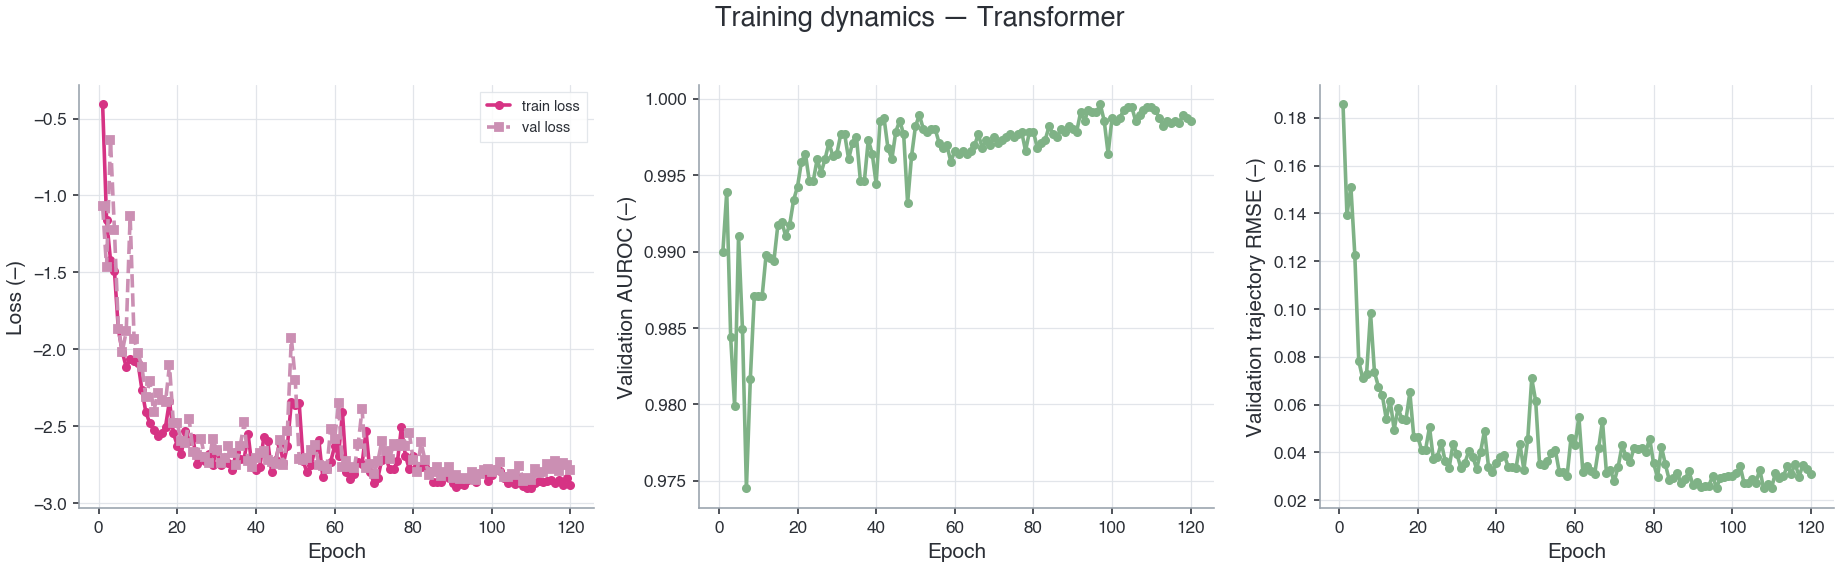

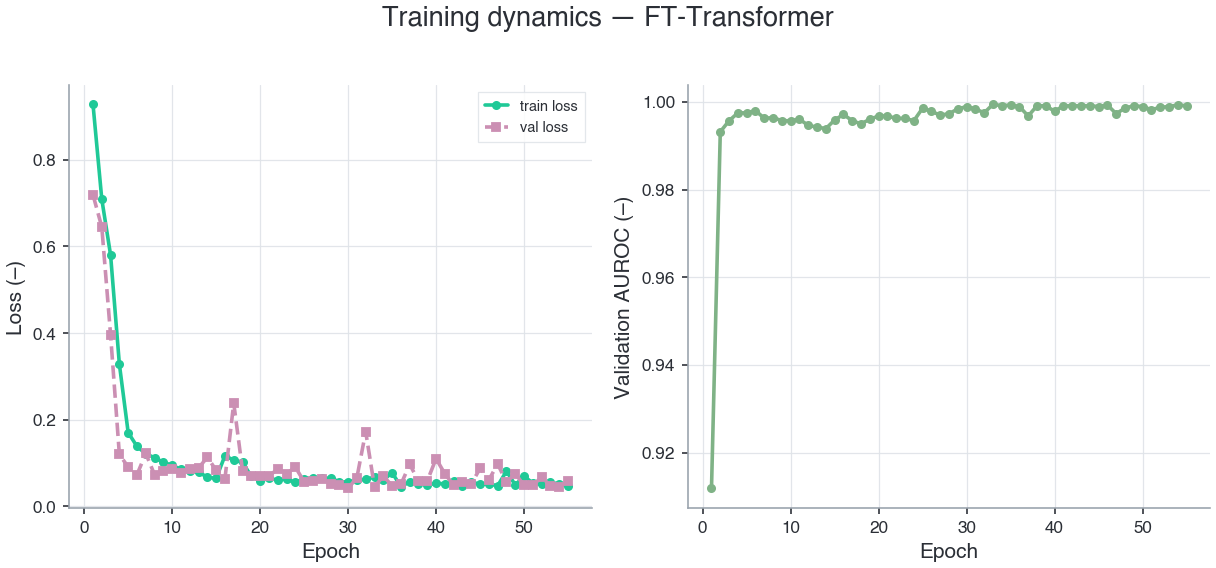

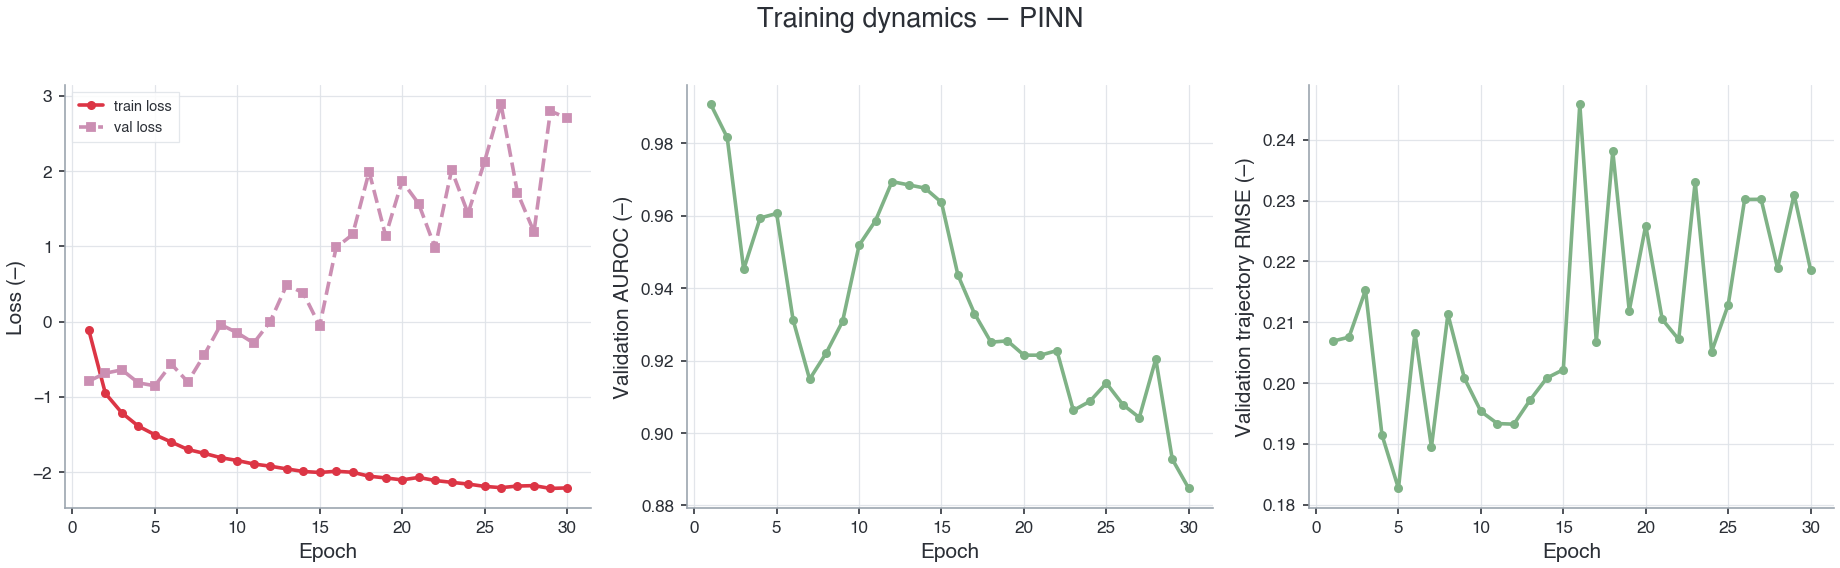

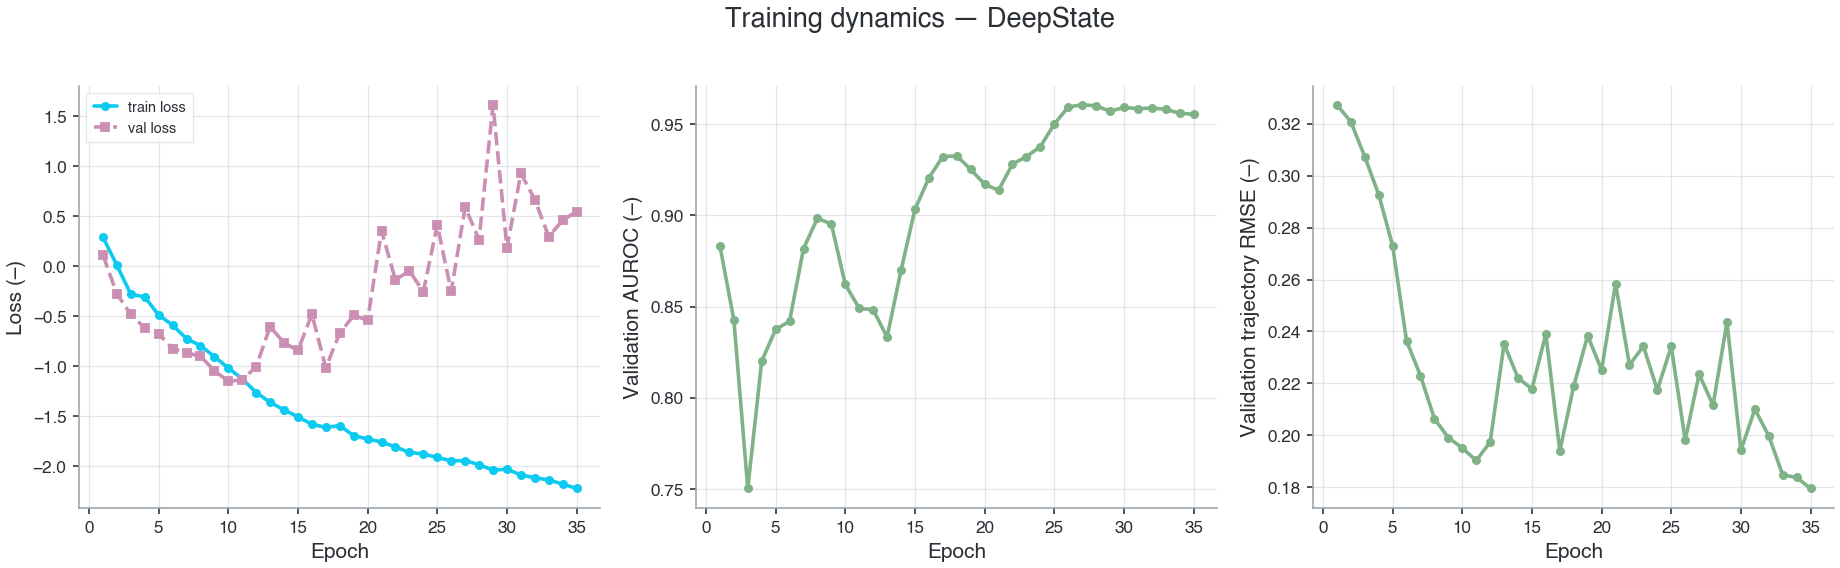

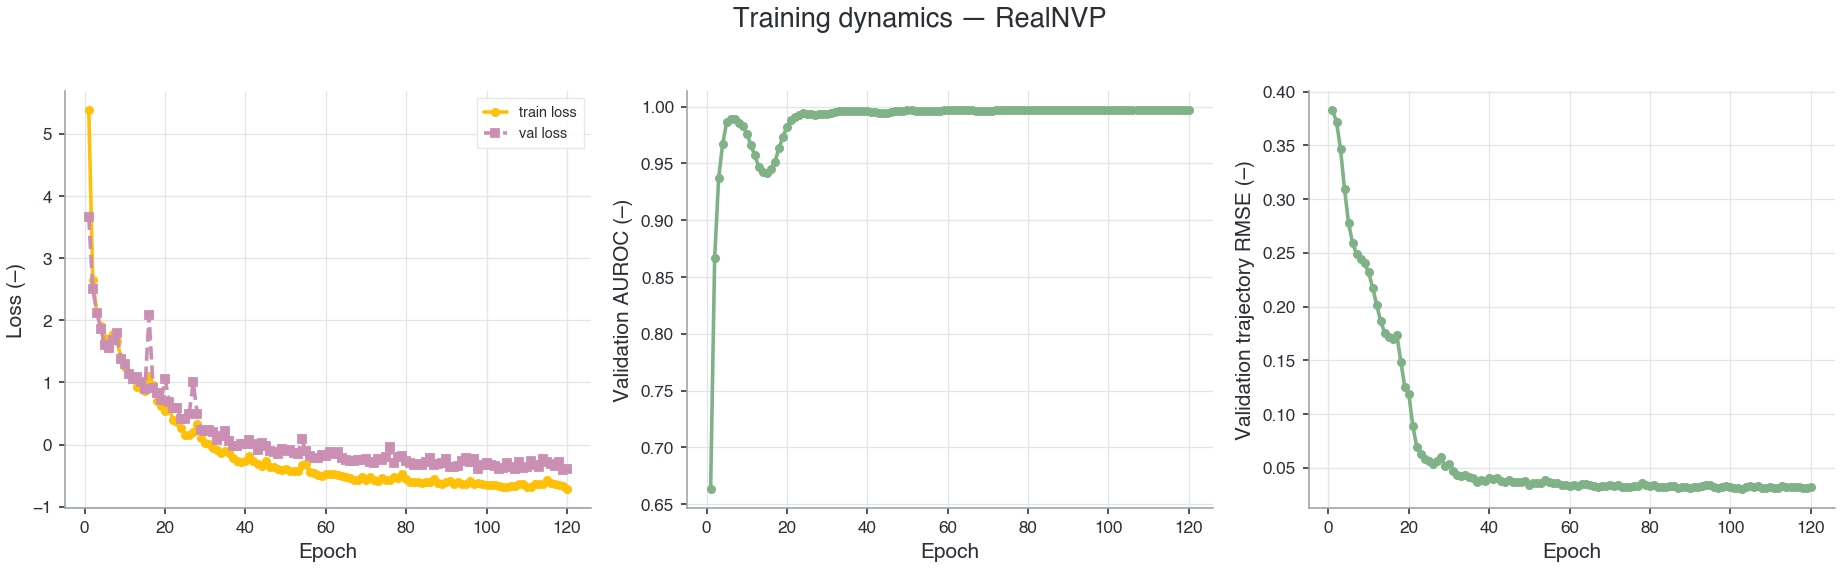

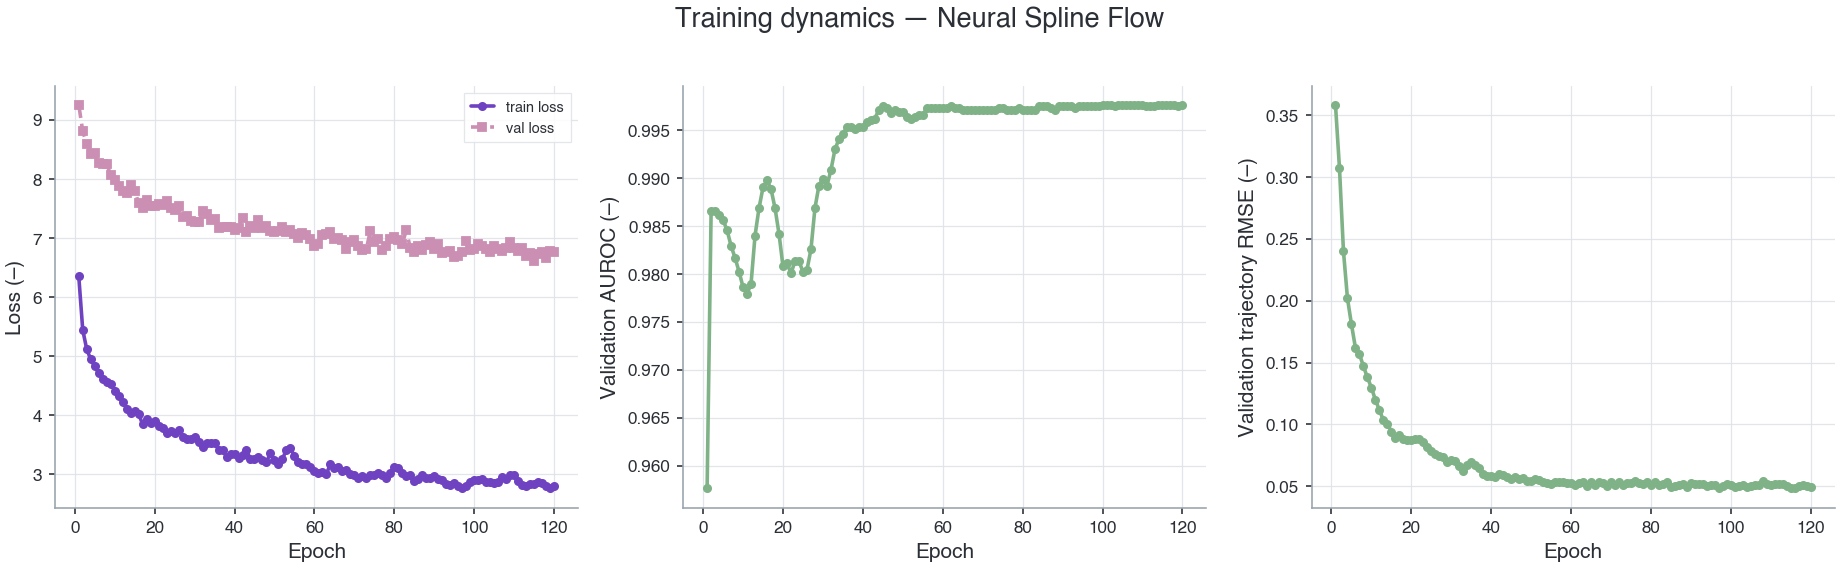

In [5]:
palette = ["#0b6efd", "#198754", "#fd7e14", "#6610f2", "#d63384", "#20c997", "#dc3545", "#0dcaf0", "#ffc107", "#6f42c1"]
colors = {disp: palette[i % len(palette)] for i, disp in enumerate(histories)}
for disp, hist in histories.items():
    training_dashboard(hist, title=f"Training dynamics — {disp}", model_color=colors[disp],
                       save=SAVE_FIGS, fig_id=f"2_1_training_{disp.lower().replace('-', '_')}").show()

## Итог

Базовые модели подобраны grid search (с выбором метрики) и обучены. Дальше — **2.2 DPI-Flow**.

In [6]:
# --- CatBoost (табличный градиентный бустинг) ---
# Не нейросеть, поэтому обучается своим .fit (не train_model) и сохраняется нативно.
cb = CatBoostBaseline(static_dim, prefix_dim).fit(benchmark["train"], benchmark["val"])
cb.save(MODELS_DIR, "catboost")
write_hyperparams(MODELS_DIR, "catboost", {"model_type": "CatBoostBaseline", "display_name": "CatBoost",
                  "model_kwargs": dict(static_dim=static_dim, prefix_dim=prefix_dim)})
print("saved:", MODELS_DIR / "catboost")

saved: /Users/nikita/Desktop/projects/liquefaction-ai/models/catboost
